### compare FMG results between GTDB rs220 vs rs226 using your two summary files:

- 1901_summary_220_k21.csv
- 1901_summary_226_k21.csv

- db location:
/group/ctbrowngrp5/sourmash-db.new/gtdb-rs226/
- quantify per-sample differences in:
    - ref_f_unweighted
    - ref_f_weighted
    - n_matches

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# File paths
# -----------------------
f220 = "../../data/1901_summary_220_k21.csv"
f226 = "../../data/1901_summary_226_k21.csv"
biome_file = "../../data/zyzhao-list-oct3.csv"

# -----------------------
# Load only needed columns
# -----------------------
df220 = pd.read_csv(
    f220,
    usecols=["accession", "ref_f_unweighted", "ref_f_weighted", "n_matches"]
)

df226 = pd.read_csv(
    f226,
    usecols=["accession", "ref_f_unweighted", "ref_f_weighted", "n_matches"]
)

biome_df = pd.read_csv(
    biome_file,
    usecols=["accession", "biome3"]
)

# -----------------------
# Rename version-specific columns
# -----------------------
df220 = df220.rename(columns={
    "ref_f_unweighted": "ref_f_unweighted_220",
    "ref_f_weighted": "ref_f_weighted_220",
    "n_matches": "n_matches_220"
})

df226 = df226.rename(columns={
    "ref_f_unweighted": "ref_f_unweighted_226",
    "ref_f_weighted": "ref_f_weighted_226",
    "n_matches": "n_matches_226"
})

# -----------------------
# Merge all three
# -----------------------
merged = (
    df220
    .merge(df226, on="accession", how="inner")
    .merge(biome_df, on="accession", how="inner")
)

# -----------------------
# Explicit column order
# -----------------------
merged = merged[
    [
        "accession",
        "biome3",
        "ref_f_unweighted_220",
        "ref_f_weighted_220",
        "n_matches_220",
        "ref_f_unweighted_226",
        "ref_f_weighted_226",
        "n_matches_226",
    ]
]

# -----------------------
# Save
# -----------------------
# merged.to_csv("1901_merged_220_226_with_biome.csv", index=False)

print("Final shape:", merged.shape)
print(merged.head())

Final shape: (1901, 8)
   accession                                      biome3  \
0  DRR014782  Host-associated:Mammals:Respiratory system   
1  DRR014785  Host-associated:Mammals:Respiratory system   
2  DRR019499    Host-associated:Insecta:Digestive system   
3  DRR042462      Host-associated:Human:Digestive system   
4  DRR042463      Host-associated:Human:Digestive system   

   ref_f_unweighted_220  ref_f_weighted_220  n_matches_220  \
0              0.733621            0.949541          12389   
1              0.728105            0.946977          13328   
2              0.268765            0.259064          21126   
3              0.901071            0.965085           3213   
4              0.815821            0.937989           4229   

   ref_f_unweighted_226  ref_f_weighted_226  n_matches_226  
0              0.744218            0.951303          13557  
1              0.740073            0.949255          14609  
2              0.297762            0.295750          23740  

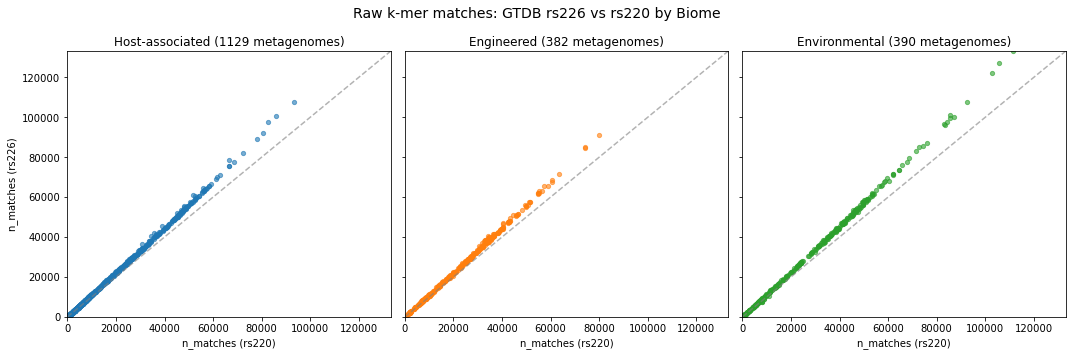

In [2]:
import matplotlib.pyplot as plt

# -----------------------
# Extract first-level biome
# -----------------------
merged["biome1"] = (
    merged["biome3"]
    .str.split(":").str[0]
    .str.strip()
)

# Define biome order + colors
biomes = ["Host-associated", "Engineered", "Environmental"]

biome_colors = {
    "Host-associated": "#1f77b4",
    "Engineered": "#ff7f0e",
    "Environmental": "#2ca02c"
}

# Global axis limits (important for visual comparison)
max_val = max(
    merged["n_matches_220"].max(),
    merged["n_matches_226"].max()
)

# -----------------------
# Create subplots
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

for ax, biome in zip(axes, biomes):
    
    sub = merged[merged["biome1"] == biome]
    
    ax.scatter(
        sub["n_matches_220"],
        sub["n_matches_226"],
        s=18,
        alpha=0.6,
        color=biome_colors[biome]
    )
    

    # 1:1 line
    ax.plot([0, max_val], [0, max_val],
            "--", color="gray", linewidth=1.5, alpha=0.6)
    
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    
    # ax.set_title(biome)
    ax.set_title(f"{biome} ({len(sub)} metagenomes)")
    ax.set_xlabel("n_matches (rs220)")

# Only left panel gets y-label
axes[0].set_ylabel("n_matches (rs226)")

plt.suptitle("Raw k-mer matches: GTDB rs226 vs rs220 by Biome", fontsize=14)
plt.tight_layout()
plt.show()